<a href="https://colab.research.google.com/github/Ritapaz/simulacao-logistica/blob/filas/Simula%C3%A7%C3%A3o_Log%C3%ADstica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install simpy

Caminhão 1 chegou às 36.73
Caminhão 1 começou a carregar após 0.00 minutos de espera
Caminhão 2 chegou às 49.03
Caminhão 2 começou a carregar após 0.00 minutos de espera
Caminhão 3 chegou às 49.50
Caminhão 1 terminou às 51.73
Caminhão 3 começou a carregar após 2.22 minutos de espera
Caminhão 2 terminou às 64.03
Caminhão 3 terminou às 66.73
Caminhão 4 chegou às 89.17
Caminhão 4 começou a carregar após 0.00 minutos de espera
Caminhão 4 terminou às 104.17


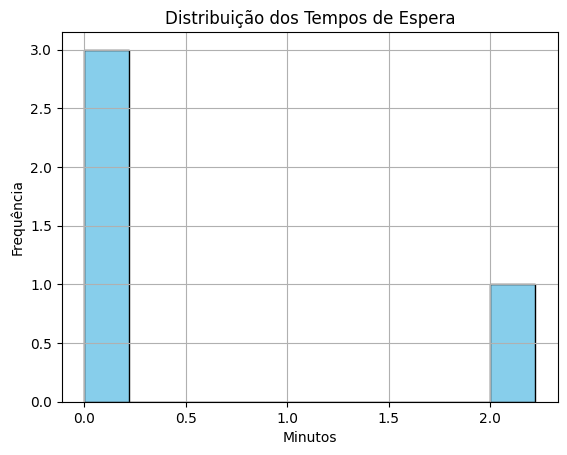

In [2]:
import simpy
import random
import matplotlib.pyplot as plt

TEMPO_SIMULACAO = 120  # minutos
TEMPO_ATENDIMENTO = 15  # minutos
CHEGADAS_POR_HORA = 4  # média de caminhões/hora

chegadas = []
esperas = []

def caminhão(env, nome, docas):
    chegada = env.now
    chegadas.append(chegada)
    print(f"{nome} chegou às {chegada:.2f}")

    with docas.request() as req:
        yield req
        espera = env.now - chegada
        esperas.append(espera)
        print(f"{nome} começou a carregar após {espera:.2f} minutos de espera")
        yield env.timeout(TEMPO_ATENDIMENTO)
        print(f"{nome} terminou às {env.now:.2f}")

def chegada_caminhoes(env, docas):
    i = 0
    while True:
        yield env.timeout(random.expovariate(CHEGADAS_POR_HORA / 60))
        i += 1
        env.process(caminhão(env, f'Caminhão {i}', docas))

env = simpy.Environment()
docas = simpy.Resource(env, capacity=2)
env.process(chegada_caminhoes(env, docas))
env.run(until=TEMPO_SIMULACAO)

# Análise gráfica
plt.hist(esperas, bins=10, color='skyblue', edgecolor='black')
plt.title("Distribuição dos Tempos de Espera")
plt.xlabel("Minutos")
plt.ylabel("Frequência")
plt.grid(True)
plt.show()


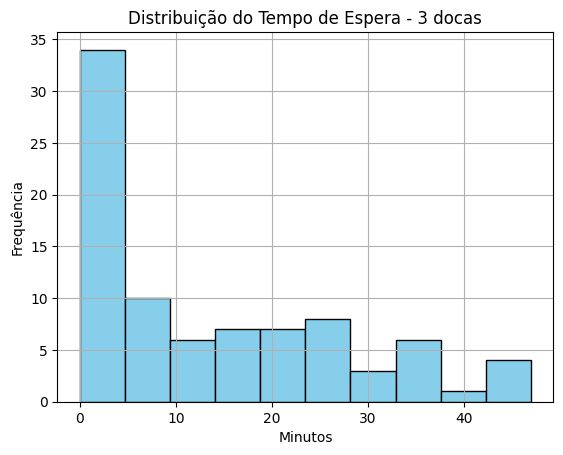

Tempo médio de espera: 13.58 minutos
Número de caminhões atendidos: 86


In [3]:
import simpy
import random
import matplotlib.pyplot as plt

TEMPO_SIMULACAO = 500
TEMPO_ATENDIMENTO = 15
TAXA_CHEGADA = 10  # caminhões por hora

esperas = []

def caminhão(env, nome, docas):
    chegada = env.now
    with docas.request() as req:
        yield req
        espera = env.now - chegada
        esperas.append(espera)
        yield env.timeout(TEMPO_ATENDIMENTO)

def chegada_caminhoes(env, docas):
    i = 0
    while True:
        yield env.timeout(random.expovariate(TAXA_CHEGADA / 60))
        i += 1
        env.process(caminhão(env, f'Caminhão {i}', docas))

def simular(capacidade_docas=2):
    global esperas
    esperas = []
    env = simpy.Environment()
    docas = simpy.Resource(env, capacity=capacidade_docas)
    env.process(chegada_caminhoes(env, docas))
    env.run(until=TEMPO_SIMULACAO)

    plt.hist(esperas, bins=10, color='skyblue', edgecolor='black')
    plt.title(f"Distribuição do Tempo de Espera - {capacidade_docas} docas")
    plt.xlabel("Minutos")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.show()

    print(f"Tempo médio de espera: {sum(esperas)/len(esperas):.2f} minutos")
    print(f"Número de caminhões atendidos: {len(esperas)}")

# Simular para 3 docas, por exemplo:
simular(capacidade_docas=3)


In [9]:
import simpy
import random
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider

def simular_fila(capacidade_docas, taxa_chegada, tempo_servico, tempo_total):
    random.seed(42)
    esperas = []

    def caminhão(env, nome, docas):
        chegada = env.now
        with docas.request() as req:
            yield req
            espera = env.now - chegada
            esperas.append(espera)
            yield env.timeout(tempo_servico)

    def chegada_caminhoes(env, docas):
        i = 0
        while True:
            yield env.timeout(random.expovariate(taxa_chegada / 60))
            i += 1
            env.process(caminhão(env, f'Caminhão {i}', docas))

    env = simpy.Environment()
    docas = simpy.Resource(env, capacity=capacidade_docas)
    env.process(chegada_caminhoes(env, docas))
    env.run(until=tempo_total)

    # Plot
    plt.figure(figsize=(10, 5))
    plt.hist(esperas, bins=15, color='lightblue', edgecolor='black')
    plt.title(f"Distribuição do Tempo de Espera\n{capacidade_docas} docas, chegada {taxa_chegada}/h, serviço {tempo_servico} min")
    plt.xlabel("Minutos de espera")
    plt.ylabel("Frequência")
    plt.grid(True)
    plt.show()

    print(f"Tempo médio de espera: {sum(esperas)/len(esperas):.2f} min")
    print(f"Número total de caminhões atendidos: {len(esperas)}")

"""interact(
    simular_fila,
    capacidade_docas=IntSlider(min=1, max=5, step=1, value=2, description='Docas'),
    taxa_chegada=IntSlider(min=2, max=20, step=1, value=5, description='Chegadas/h'),
    tempo_servico=IntSlider(min=5, max=30, step=1, value=15, description='Serviço (min)'),
    tempo_total=IntSlider(min=60, max=480, step=30, value=240, description='Tempo Sim. (min)')
)"""


"interact(\n    simular_fila,\n    capacidade_docas=IntSlider(min=1, max=5, step=1, value=2, description='Docas'),\n    taxa_chegada=IntSlider(min=2, max=20, step=1, value=5, description='Chegadas/h'),\n    tempo_servico=IntSlider(min=5, max=30, step=1, value=15, description='Serviço (min)'),\n    tempo_total=IntSlider(min=60, max=480, step=30, value=240, description='Tempo Sim. (min)')\n)"